In [3]:
%pip install pandas seaborn matplotlib

  Using cached pandas-3.0.6-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached numpy-2.5.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached contourpy-1.4.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (130 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached pandas-3.0.6-cp314-cp314-macosx_11_0_arm64.whl (10.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.4.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("empirical_results.csv")
df.head()

,InputSize,Time,Trial,Algorithm,Experiment
0,2,0.000004,1,Brute Force,Comparison
1,2,0.000092,2,Brute Force,Comparison
2,2,0.000001,3,Brute Force,Comparison
3,2,0.000001,4,Brute Force,Comparison
4,2,0.000001,5,Brute Force,Comparison


In [7]:
# Split the results by experiment so the two input-size ranges are not mixed.
comparison = df[df["Experiment"] == "Comparison"]
scalability = df[df["Experiment"] == "Scalability"]

# Use the same color for each algorithm in every plot.
algorithms = ["Brute Force", "Matrix Baseline", "Greedy"]
palette = dict(zip(algorithms, sns.color_palette(n_colors=len(algorithms))))

In [8]:
# Median time in seconds over the 5 trials (the values plotted below).
summary = df.pivot_table(index=["Experiment", "InputSize"], columns="Algorithm",
                         values="Time", aggfunc="median")
summary[algorithms]

Algorithm              Brute Force  Matrix Baseline        Greedy
Experiment  InputSize                                            
Comparison  2             0.000001     6.670016e-07  2.500019e-07
            3             0.000004     5.840047e-07  2.910019e-07
            4             0.000024     7.499984e-07  2.919987e-07
            5             0.000190     1.041997e-06  3.329988e-07
            6             0.001582     1.291999e-06  4.160029e-07
            7             0.015127     1.583001e-06  4.580070e-07
            8             0.187839     2.042005e-06  5.000038e-07
            9             2.329897     2.375004e-06  5.409966e-07
Scalability 100                NaN     2.943750e-04  7.250004e-06
            500                NaN     8.624500e-03  4.629200e-05
            1000               NaN     3.651367e-02  1.150840e-04
            2000               NaN     1.495375e-01  2.549160e-04
            3000               NaN     3.440935e-01  4.302500e-04
            5000               NaN              NaN  7.263750e-04
            10000              NaN              NaN  1.637208e-03
            20000              NaN              NaN  3.329667e-03
            50000              NaN              NaN  8.625834e-03
            100000             NaN              NaN  1.726858e-02

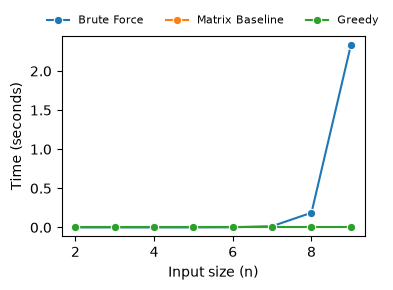

In [9]:
# Experiment 1 (Comparison): all three algorithms on small inputs, linear scale.
plt.figure(figsize=(4, 3))
ax = sns.lineplot(data=comparison, x="InputSize", y="Time", hue="Algorithm",
                  palette=palette, estimator="median", errorbar=None, marker="o")
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, 1), ncol=3,
                title=None, frameon=False, fontsize=8)
plt.xlabel("Input size (n)")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.savefig("comparison_plot.png", dpi=200)
plt.show()

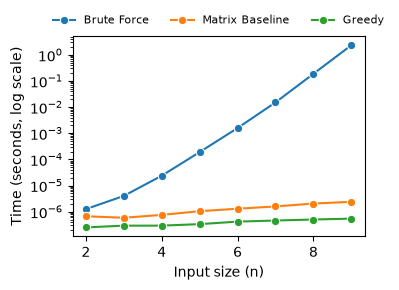

In [10]:
# Experiment 1 (Comparison): same data with a logarithmic time axis.
plt.figure(figsize=(4, 3))
ax = sns.lineplot(data=comparison, x="InputSize", y="Time", hue="Algorithm",
                  palette=palette, estimator="median", errorbar=None, marker="o")
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, 1), ncol=3,
                title=None, frameon=False, fontsize=8)
plt.xlabel("Input size (n)")
plt.ylabel("Time (seconds, log scale)")
plt.yscale("log")
plt.tight_layout()
plt.savefig("comparison_plot_log.png", dpi=200)
plt.show()

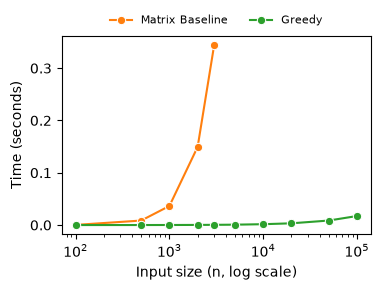

In [11]:
# Experiment 2 (Scalability): matrix baseline vs. greedy on large inputs, linear time axis.
plt.figure(figsize=(4, 3))
ax = sns.lineplot(data=scalability, x="InputSize", y="Time", hue="Algorithm",
                  palette=palette, estimator="median", errorbar=None, marker="o")
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, 1), ncol=3,
                title=None, frameon=False, fontsize=8)
plt.xlabel("Input size (n, log scale)")
plt.ylabel("Time (seconds)")
plt.xscale("log")
plt.tight_layout()
plt.savefig("scalability_plot.png", dpi=200)
plt.show()

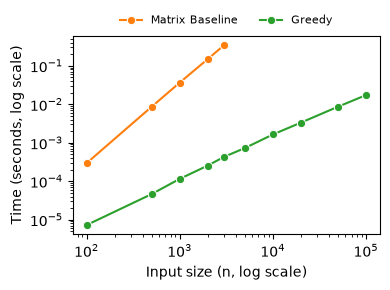

In [12]:
# Experiment 2 (Scalability): same data with logarithmic scales on both axes.
plt.figure(figsize=(4, 3))
ax = sns.lineplot(data=scalability, x="InputSize", y="Time", hue="Algorithm",
                  palette=palette, estimator="median", errorbar=None, marker="o")
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, 1), ncol=3,
                title=None, frameon=False, fontsize=8)
plt.xlabel("Input size (n, log scale)")
plt.ylabel("Time (seconds, log scale)")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.savefig("scalability_plot_log.png", dpi=200)
plt.show()